In [1]:
from utils.datasets import YOLOPoseDataset
from utils.validation import YPSetValidation
from utils.validation import save_distance_anomaly_report, compare_results_txt_to_distance_anomalies


c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    BayesianRidge, HuberRegressor, RANSACRegressor
)
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

DEFAULT_REGRESSORS = {
    'linear': LinearRegression,
    'ridge': Ridge,
    'lasso': Lasso,
    'elasticnet': ElasticNet,
    'bayesian_ridge': BayesianRidge,
    'huber': HuberRegressor,
    'ransac': RANSACRegressor,
    'svr': SVR,
    'decision_tree': lambda: DecisionTreeRegressor(random_state=42),
    'random_forest': RandomForestRegressor,
    'gradient_boosting': lambda: GradientBoostingRegressor(random_state=42),
    'hist_gradient_boosting': HistGradientBoostingRegressor,
    'knn': KNeighborsRegressor,
    'mlp': lambda: MLPRegressor(max_iter=1000, random_state=42),
}


In [4]:

def test_distance_models(x,model_type="knn"):
        dataset = YOLOPoseDataset(r"D:\Politechnika\Deadlift_publikacja_nr_2\tiger_pose_walidacja\tiger-pose_angle_preserving_out_"+str(x)+r"\train.txt")
        validator = YPSetValidation(dataset)
        distance_model,valid_indices=validator.train_distance_models(model_type)
        results_distance_tiger=validator.predict_distance_anomalies(distance_model,valid_indices,threshold_percentile=95)
        distance_report_path = r"D:\Politechnika\Deadlift_publikacja_nr_2\weryfikacje_weryfikacji\tiger\distance_anomalies_tiger_" + str(x) + ".txt"
        reference_results_txt_path = r"D:\Politechnika\Deadlift_publikacja_nr_2\tiger_pose_walidacja\tiger-pose_angle_preserving_out_"+str(x)+r"\results.txt"
        save_distance_anomaly_report(results_distance_tiger, distance_report_path)
        comparison = compare_results_txt_to_distance_anomalies(
            reference_results_txt_path=reference_results_txt_path,
            distance_anomaly_report_path=distance_report_path,
            top_k=x,
            include_reference_fields=True,
            match_mode="auto",
        )

        print(comparison["summary_text"])
        return comparison

for name,cls in DEFAULT_REGRESSORS.items():
    print(f"Testing distance model: {name}")
    test_distance_models(100,name)


Testing distance model: linear


Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 131.95it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 131.41it/s]


W top 100 pozycji rankingu anomalii znajduje się 68 poprawnych plików (plików z results.txt), a ostatni z nich zajmuje pozycję 100. Średnia pozycja wszystkich poszukiwanych: 78.8.
Testing distance model: ridge


Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 131.00it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 132.00it/s]


W top 100 pozycji rankingu anomalii znajduje się 65 poprawnych plików (plików z results.txt), a ostatni z nich zajmuje pozycję 100. Średnia pozycja wszystkich poszukiwanych: 82.6.
Testing distance model: lasso


...

W top 100 pozycji rankingu anomalii znajduje się 70 poprawnych plików (plików z results.txt), a ostatni z nich zajmuje pozycję 95. Średnia pozycja wszystkich poszukiwanych: 75.7.
Testing distance model: knn


Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 131.79it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 132.66it/s]


W top 100 pozycji rankingu anomalii znajduje się 68 poprawnych plików (plików z results.txt), a ostatni z nich zajmuje pozycję 95. Średnia pozycja wszystkich poszukiwanych: 77.5.
Testing distance model: mlp


Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 132.29it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 132.37it/s]


W top 100 pozycji rankingu anomalii znajduje się 62 poprawnych plików (plików z results.txt), a ostatni z nich zajmuje pozycję 100. Średnia pozycja wszystkich poszukiwanych: 91.7.


Testing distance model: linear


Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 133.58it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 131.72it/s]


W top 100 pozycji rankingu anomalii znajduje się 68 poprawnych plików (plików z results.txt), a ostatni z nich zajmuje pozycję 100. Średnia pozycja wszystkich poszukiwanych: 78.8.
Testing distance model: ridge


Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 131.42it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 132.40it/s]


W top 100 pozycji rankingu anomalii znajduje się 65 poprawnych plików (plików z results.txt), a ostatni z nich zajmuje pozycję 100. Średnia pozycja wszystkich poszukiwanych: 82.6.
Testing distance model: lasso


...

W top 100 pozycji rankingu anomalii znajduje się 70 poprawnych plików (plików z results.txt), a ostatni z nich zajmuje pozycję 95. Średnia pozycja wszystkich poszukiwanych: 75.7.
Testing distance model: knn


Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 128.44it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 124.72it/s]


W top 100 pozycji rankingu anomalii znajduje się 68 poprawnych plików (plików z results.txt), a ostatni z nich zajmuje pozycję 95. Średnia pozycja wszystkich poszukiwanych: 77.5.
Testing distance model: mlp


Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 123.22it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 120.90it/s]


W top 100 pozycji rankingu anomalii znajduje się 62 poprawnych plików (plików z results.txt), a ostatni z nich zajmuje pozycję 100. Średnia pozycja wszystkich poszukiwanych: 91.7.


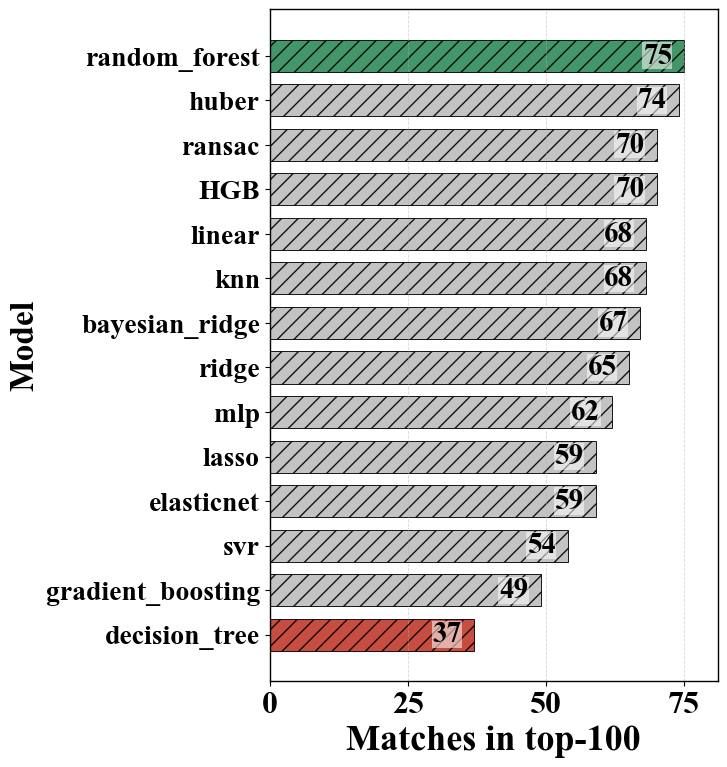

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Benchmark and publication-style comparison plot for distance models.
TOP_K_BENCH = 100
model_names = list(DEFAULT_REGRESSORS.keys())

benchmark_rows = []
for model_name in model_names:
    print(f"Testing distance model: {model_name}")
    comparison = test_distance_models(TOP_K_BENCH, model_name)
    benchmark_rows.append(
        {
            "model": model_name,
            "matched_top_k_count": int(comparison.get("matched_top_k_count", 0)),
        }
    )

if not benchmark_rows:
    raise RuntimeError("No benchmark results available for plotting.")

# Sort by top-k matches (higher is better).
benchmark_rows.sort(key=lambda row: -row["matched_top_k_count"])

models = [row["model"] for row in benchmark_rows]
matched_top_k = np.array([row["matched_top_k_count"] for row in benchmark_rows], dtype=float)
y_pos = np.arange(len(models))

# Shorten selected labels for publication readability.
model_label_map = {
    "hist_gradient_boosting": "HGB",
}
display_models = [model_label_map.get(name, name) for name in models]

# IEEE-like styling consistent with previous figures.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.linewidth": 1.0,
})

base_color = "#BDBDBD"
best_color = "#2E8B57"
worst_color = "#C0392B"

colors_top = [base_color] * len(models)
if len(models) > 0:
    best_top_idx = int(np.argmax(matched_top_k))
    worst_top_idx = int(np.argmin(matched_top_k))
    colors_top[best_top_idx] = best_color
    colors_top[worst_top_idx] = worst_color

# Square figure (1:1) with slightly larger width for better readability.
fig, ax = plt.subplots(1, 1, figsize=(8.0, 8.0))
bars = ax.barh(
    y_pos,
    matched_top_k,
    color=colors_top,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.9,
    height=0.72,
    hatch="//",
)

ax.set_yticks(y_pos)
ax.set_yticklabels(display_models, fontsize=20, fontweight="bold")
ax.invert_yaxis()
ax.set_xlabel(f"Matches in top-{TOP_K_BENCH}", fontsize=26, fontweight="bold")
ax.set_ylabel("Model", fontsize=24, fontweight="bold")
ax.tick_params(axis="x", labelsize=23)
for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")
ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.5)

# Keep right margin so full 'top-100' context and value labels remain visible.
xmax = float(np.max(matched_top_k)) if len(matched_top_k) else 1.0
ax.set_xlim(0, xmax * 1.08)

# Put effectiveness values inside bars, bold and high-contrast.
for bar, value in zip(bars, matched_top_k):
    width = float(bar.get_width())
    text_x = width - max(0.6, 0.03 * xmax)
    ha = "right"
    if text_x <= 0.35:
        text_x = width * 0.5
        ha = "center"
    ax.text(
        text_x,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value)}",
        ha=ha,
        va="center",
        fontsize=21,
        fontweight="bold",
        color="black",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.55, "pad": 0.4},
    )

fig.subplots_adjust(left=0.42, right=0.98, bottom=0.14, top=0.98)
plt.show()

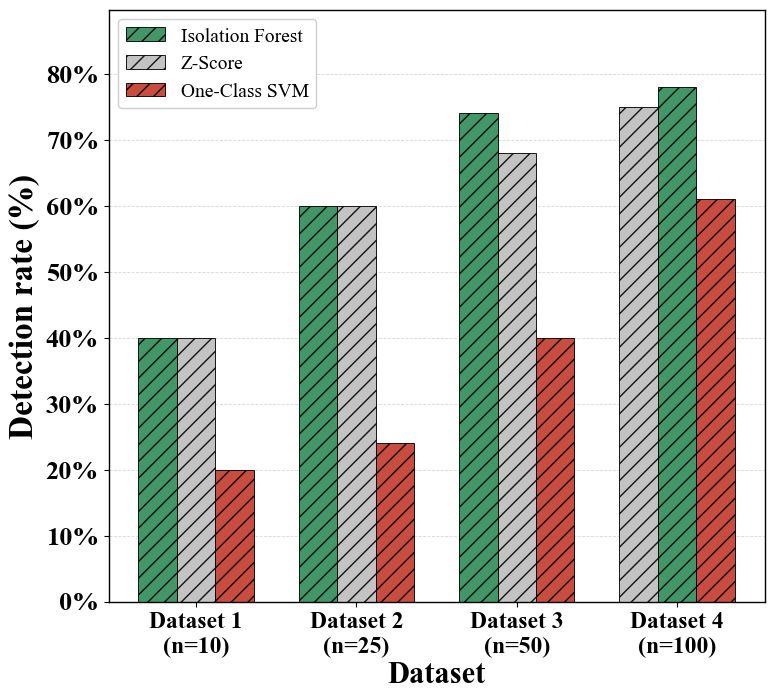

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Tabular detection results (detected count / total).
labels = ["Dataset 1\n(n=10)", "Dataset 2\n(n=25)", "Dataset 3\n(n=50)", "Dataset 4\n(n=100)"]

totals = np.array([10, 25, 50, 100], dtype=float)
isolation_forest = np.array([4, 15, 37, 75], dtype=float)
z_score = np.array([4, 15, 34, 78], dtype=float)
one_class_svm = np.array([2, 6, 20, 61], dtype=float)

# Convert raw counts to percentages.
pct_if = (isolation_forest / totals) * 100.0
pct_zs = (z_score / totals) * 100.0
pct_svm = (one_class_svm / totals) * 100.0

method_series = [
    ("Isolation Forest", pct_if, isolation_forest),
    ("Z-Score", pct_zs, z_score),
    ("One-Class SVM", pct_svm, one_class_svm),
]

# IEEE-like styling aligned with the previous benchmark chart.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.linewidth": 1.0,
})

base_color = "#BDBDBD"
best_color = "#2E8B57"
worst_color = "#C0392B"

pct_matrix = np.vstack([pct_if, pct_zs, pct_svm])
best_idx = np.argmax(pct_matrix, axis=0)
worst_idx = np.argmin(pct_matrix, axis=0)

x = np.arange(len(labels))
width = 0.24

# Square figure to match 1:1 publication format from cell 4.
fig, ax = plt.subplots(1, 1, figsize=(8.0, 8.0))

for method_idx, (name, pct_values, _raw_values) in enumerate(method_series):
    offset = (method_idx - 1) * width
    colors = [base_color] * len(labels)
    for dataset_idx in range(len(labels)):
        if method_idx == int(best_idx[dataset_idx]):
            colors[dataset_idx] = best_color
        elif method_idx == int(worst_idx[dataset_idx]):
            colors[dataset_idx] = worst_color

    ax.bar(
        x + offset,
        pct_values,
        width,
        label=name,
        color=colors,
        edgecolor="black",
        linewidth=0.7,
        alpha=0.9,
        hatch="//",
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=17, fontweight="bold")
ax.set_ylabel("Detection rate (%)", fontsize=24, fontweight="bold")
ax.set_xlabel("Dataset", fontsize=22, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis="y", labelsize=19)
for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

ymax = float(np.max(pct_matrix)) if pct_matrix.size else 100.0
ax.set_ylim(0, ymax * 1.15)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax.set_axisbelow(True)
ax.legend(framealpha=0.95, fontsize=14, loc="upper left")

fig.subplots_adjust(left=0.16, right=0.98, bottom=0.18, top=0.92)
plt.show()

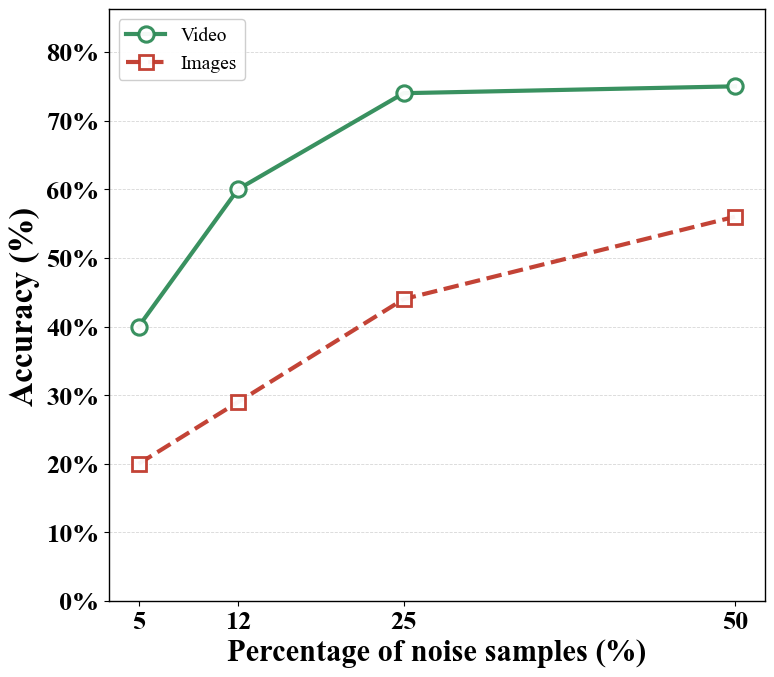

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

x_values = np.array([5, 12.5, 25, 50], dtype=float)
video = np.array([40, 60, 74, 75], dtype=float)
images = np.array([20, 29, 44, 56], dtype=float)

# IEEE-like styling aligned with previous figures.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.linewidth": 1.0,
})

color_video = "#2E8B57"
color_images = "#C0392B"

# Keep 1:1 format and strong typography consistent with earlier charts.
fig, ax = plt.subplots(1, 1, figsize=(8.0, 8.0))

ax.plot(
    x_values,
    video,
    marker="o",
    markersize=11,
    linewidth=3.0,
    label="Video",
    color=color_video,
    linestyle="-",
    markerfacecolor="white",
    markeredgewidth=2.2,
    alpha=0.95,
    zorder=3,
    )
ax.plot(
    x_values,
    images,
    marker="s",
    markersize=10,
    linewidth=3.0,
    label="Images",
    color=color_images,
    linestyle="--",
    markerfacecolor="white",
    markeredgewidth=2.0,
    alpha=0.95,
    zorder=3,
    )

ax.set_xticks(x_values)
ax.set_xticklabels([str(int(v)) for v in x_values], fontsize=19, fontweight="bold")
ax.set_xlabel("Percentage of noise samples (%)", fontsize=22, fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontsize=24, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis="y", labelsize=19)
for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

xpad = (float(np.max(x_values)) - float(np.min(x_values))) * 0.05
ax.set_xlim(float(np.min(x_values)) - xpad, float(np.max(x_values)) + xpad)

ymax = float(max(np.max(video), np.max(images)))
ax.set_ylim(0, ymax * 1.15)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax.set_axisbelow(True)
ax.legend(framealpha=0.95, fontsize=14, loc="upper left")

fig.subplots_adjust(left=0.16, right=0.98, bottom=0.18, top=0.92)
plt.show()
